In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
import os, pickle as pkl
warnings.filterwarnings('ignore')

# Demographic data

In [7]:
df_results=pd.read_csv("C:/Users/THIN/OneDrive - Escuela Tecnologica Instituto Tecnico Central/Proyecto_cerebro/Code/Results/result.csv",sep=",")
df_results

,Accuraccy_train_h24-28-32_w200_ov64_120-500s,Loss_train_h24-28-32_w200_ov64_120-500s,Accuraccy_train_h24-30-36_w200_ov64_120s-500s,Loss_train_h24-30-36_w200_ov64_120s-500s,Accuraccy_train_h28-30-32_w200_ov64_120-500s,Loss_train_h28-30-32_w200_ov64_120-500s,Accuraccy_train_h28-32-36_w200_ov64_120s-500s,Loss_train_h28-32-36_w200_ov64_120s-500s,Accuraccy_train_h32-34-36_w200_ov64_120-500s,Loss_train_h32-34-36_w200_ov64_120-500s,Accuraccy_train_h38-40-42_w200_ov64_120s-500s,Loss_train_h38-40-42_w200_ov64_120s-500s,Accuraccy_train_h42-44-46_w200_ov64_120s-500s,Loss_train_h42-44-46_w200_ov64_120s-500s,Accuraccy_train_h24-28-32-36_w200_ov64_120-500s,Loss_train_h24-28-32-36_w200_ov64_120-500s,Accuraccy_train_h30-32-34-36_w200_ov64_120s-500s,Loss_train_h30-32-34-36_w200_ov64_120s-500s
0,0.589354,0.667625,0.586735,0.657439,0.592040,0.633508,0.595960,0.682978,0.592965,0.711318,0.404255,0.693711,0.600000,0.714775,0.407407,0.715566,0.594697,0.727302
1,0.589354,0.690034,0.586735,0.683286,0.592040,0.658240,0.595960,0.681209,0.592965,0.700184,0.404255,0.692697,0.600000,0.706576,0.407407,0.712482,0.594697,0.740534
2,0.624842,0.675080,0.588435,0.680380,0.620232,0.656435,0.629630,0.667346,0.623116,0.691127,0.460993,0.696801,0.600000,0.710709,0.407407,0.703879,0.628788,0.706547
3,0.634981,0.658806,0.593112,0.643238,0.620647,0.708063,0.642677,0.683682,0.621859,0.668176,0.478723,0.692641,0.595833,0.705953,0.483333,0.688938,0.610795,0.692137
4,0.645627,0.643285,0.583673,0.630446,0.617910,0.688204,0.644444,0.696548,0.623116,0.642334,0.492553,0.700289,0.584444,0.703469,0.525926,0.672721,0.610606,0.691381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.699873,0.580903,0.718318,0.585141,0.727948,0.571464,0.756323,0.520024,0.700142,0.589848,0.679513,0.592941,0.629612,0.630491,0.723800,0.513820,0.723577,0.565373
496,0.700018,0.580875,0.718423,0.584871,0.727952,0.571428,0.756519,0.519639,0.700298,0.589513,0.679587,0.592893,0.629469,0.630398,0.723951,0.513746,0.723645,0.564990
497,0.700147,0.581033,0.718537,0.584828,0.727906,0.572104,0.756653,0.519240,0.700393,0.589767,0.679791,0.592621,0.629551,0.630212,0.724071,0.513512,0.723743,0.564835
498,0.700298,0.580660,0.718580,0.584726,0.727970,0.571587,0.756837,0.519089,0.700396,0.589828,0.679961,0.592328,0.629689,0.630136,0.724235,0.513355,0.723826,0.564531


In [28]:
df_results=pd.read_csv("C:/Users/THIN/OneDrive - Escuela Tecnologica Instituto Tecnico Central/Proyecto_cerebro/Code/Results/result.csv",sep=",")
col_loss=[i for i in df_results.columns if "Loss" in i]
Accuracy=[i for i in df_results.columns if "Accuraccy" in i]
df_loss=df_results[col_loss]
df_loss.columns=[i.split(sep="_")[2] for i in col_loss]
df_acc=df_results[Accuracy]
df_acc.columns=[i.split(sep="_")[2] for i in Accuracy]

In [29]:
df_acc

,h24-28-32,h24-30-36,h28-30-32,h28-32-36,h32-34-36,h38-40-42,h42-44-46,h24-28-32-36,h30-32-34-36
0,0.589354,0.586735,0.592040,0.595960,0.592965,0.404255,0.600000,0.407407,0.594697
1,0.589354,0.586735,0.592040,0.595960,0.592965,0.404255,0.600000,0.407407,0.594697
2,0.624842,0.588435,0.620232,0.629630,0.623116,0.460993,0.600000,0.407407,0.628788
3,0.634981,0.593112,0.620647,0.642677,0.621859,0.478723,0.595833,0.483333,0.610795
4,0.645627,0.583673,0.617910,0.644444,0.623116,0.492553,0.584444,0.525926,0.610606
...,...,...,...,...,...,...,...,...,...
495,0.699873,0.718318,0.727948,0.756323,0.700142,0.679513,0.629612,0.723800,0.723577
496,0.700018,0.718423,0.727952,0.756519,0.700298,0.679587,0.629469,0.723951,0.723645
497,0.700147,0.718537,0.727906,0.756653,0.700393,0.679791,0.629551,0.724071,0.723743
498,0.700298,0.718580,0.727970,0.756837,0.700396,0.679961,0.629689,0.724235,0.723826


In [9]:
df=pd.read_csv("../d/data_patients.csv",sep=";")
df["Age"]=df["Age"].fillna(np.mean(df["Age"]))
for i in df["Sex"][df["Sex"].isnull()].index:
    df["Sex"].iloc[[i]]=np.random.choice(["Male","Female"],p=[0.7,0.3])
df.head(10)

,Id_Patient,Hospital,Age,Sex,ROSC,OHCA,Shockable Rhythm,TTM,Outcome,CPC
0,284,A,53.0,Male,NaN,True,True,33.0,Good,1
1,286,F,85.0,Female,7.0,False,False,NaN,Good,1
2,296,A,48.0,Male,NaN,True,True,36.0,Good,1
3,299,A,45.0,Male,NaN,True,True,33.0,Good,1
4,303,D,51.0,Male,24.0,True,True,33.0,Good,1
5,306,E,73.0,Male,20.0,True,False,33.0,Good,1
6,311,A,39.0,Female,NaN,True,True,33.0,Good,2
7,312,D,51.0,Male,NaN,NaN,True,NaN,Good,1
8,313,B,56.0,Male,3.0,False,False,33.0,Good,1
9,316,D,41.0,Male,37.0,True,True,33.0,Good,1


In [8]:
df.describe()

,Id_Patient,Age,ROSC,TTM,CPC
count,607.000000,607.000000,303.000000,509.000000,607.000000
mean,668.588138,61.168317,23.267327,33.359528,3.509061
std,204.331564,15.637437,18.794052,0.975291,1.831022
min,284.000000,16.000000,1.000000,33.000000,1.000000
25%,488.500000,52.000000,10.000000,33.000000,1.000000
50%,673.000000,63.000000,19.000000,33.000000,5.000000
75%,846.500000,72.000000,30.000000,33.000000,5.000000
max,1020.000000,90.000000,111.000000,36.000000,5.000000


In [14]:
da_odh["Outcome"].value_counts(normalize=True)

Outcome
Poor    0.629325
Good    0.370675
Name: proportion, dtype: float64

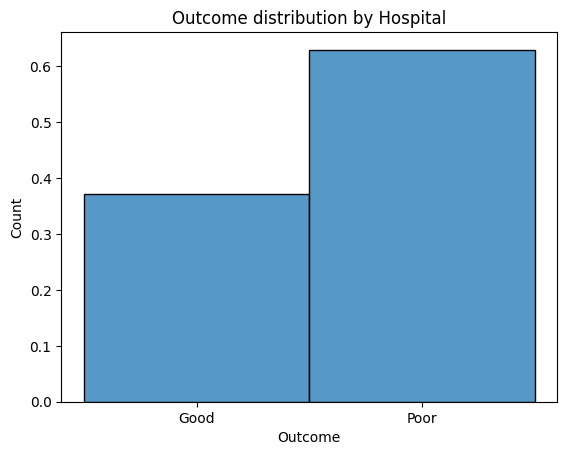

In [13]:
da_odh = df
sns.histplot(data=da_odh, x="Outcome", stat="probability")
plt.title("Outcome distribution by Hospital")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

In [10]:
data_an=pd.read_csv("d/data_features.csv", sep=";")
data_an.sort_values(by=["patient", "hour_file", "number_file"], inplace=True)
data_an.info()

<class 'pandas.core.frame.DataFrame'>
Index: 121146 entries, 0 to 121145
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id_path         121146 non-null  object 
 1   path            121146 non-null  object 
 2   data_partition  121146 non-null  object 
 3   patient         121146 non-null  int64  
 4   file            121146 non-null  object 
 5   number_file     121146 non-null  int64  
 6   hour_file       121146 non-null  int64  
 7   format_data     121146 non-null  object 
 8   file_extension  121146 non-null  object 
 9   meas_date       0 non-null       float64
 10  minutes         121146 non-null  float64
 11  #_channels      121146 non-null  float64
 12  channels        121146 non-null  object 
 13  fs              121146 non-null  float64
 14  time_points     121146 non-null  float64
dtypes: float64(5), int64(3), object(7)
memory usage: 14.8+ MB


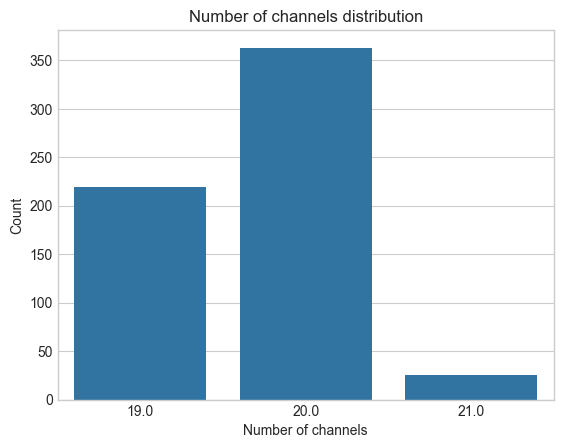

In [42]:
channels=data_an[(data_an["format_data"]=="EEG") & (data_an["file_extension"]=="hea")]
channels=channels.drop_duplicates(subset="patient")

sns.barplot(channels["#_channels"].value_counts())
plt.title("Number of channels distribution")
plt.xlabel("Number of channels")
plt.ylabel("Count")
plt.show()

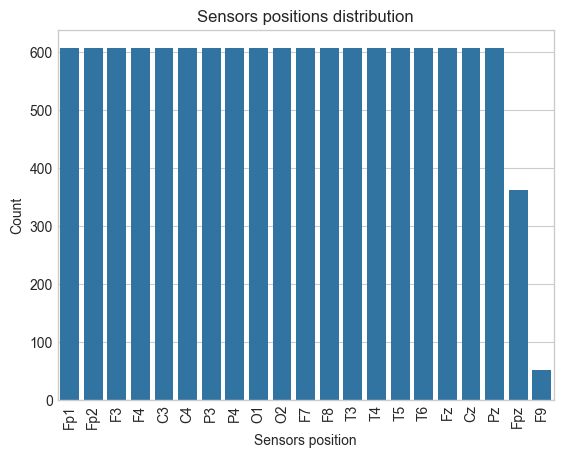

In [12]:
sensores=[]
for ch in channels["channels"]:
    sensores.extend(ch.split(sep=","))
sensores=pd.Series(sensores).value_counts()
sns.barplot(sensores)
plt.title("Sensors positions distribution")
plt.xlabel("Sensors position")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

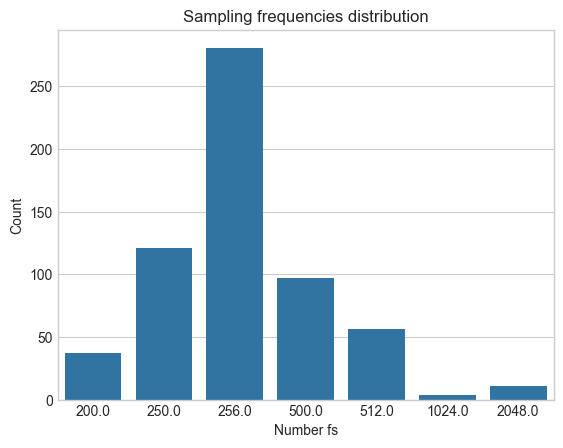

In [13]:
sns.barplot(channels["fs"].value_counts())
plt.title("Sampling frequencies distribution")
plt.xlabel("Number fs")
plt.ylabel("Count")
plt.show()

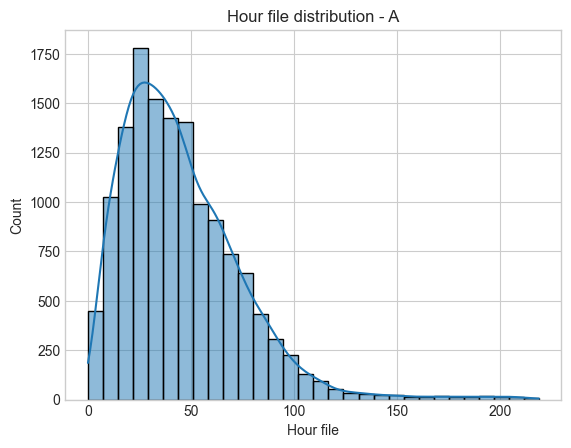

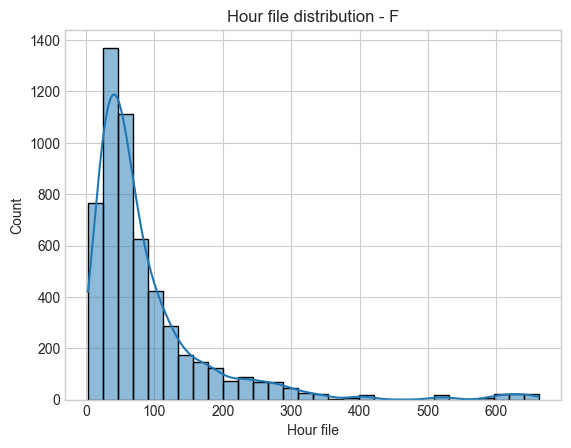

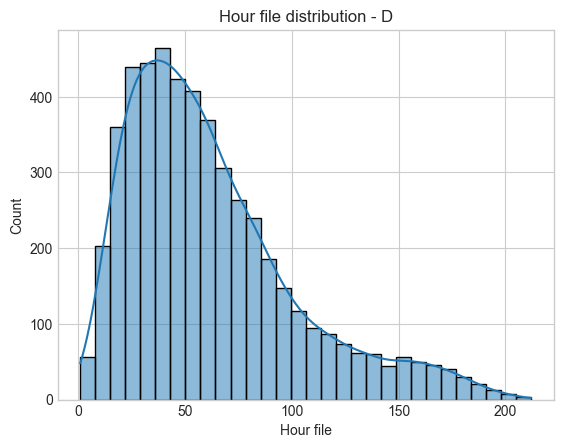

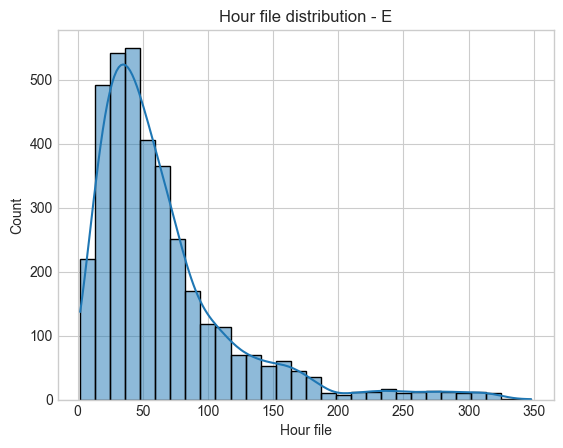

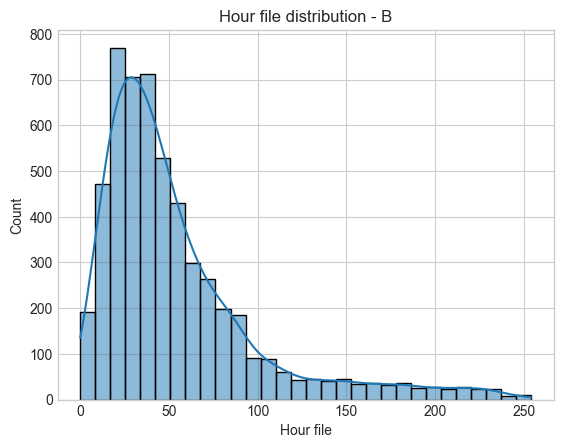

In [14]:
dat_hos=data_an[["patient", "hour_file"]].drop_duplicates().reset_index(drop=True)
data_hos=pd.merge(dat_hos, df[["Id_Patient", "Hospital"]], left_on="patient", right_on="Id_Patient", how="left").drop(columns=["Id_Patient"])
hospital=pd.unique(data_hos["Hospital"])

for h in hospital:
    plt.figure()
    sns.histplot(data=data_hos[data_hos["Hospital"]==h], x="hour_file", bins=30, kde=True)
    plt.title(f"Hour file distribution - {h}")
    plt.xlabel("Hour file")
    plt.ylabel("Count")
    plt.show()

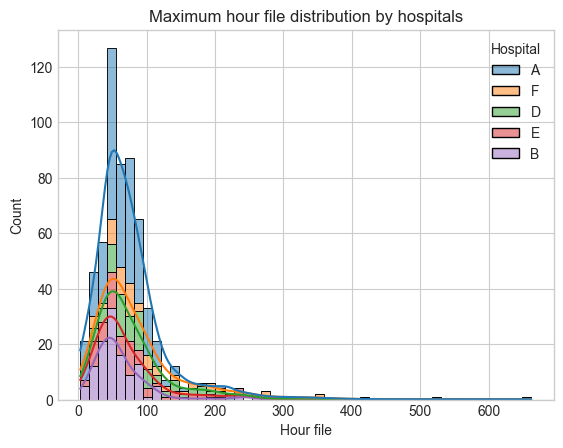

In [28]:
da_mdh=data_hos.groupby("patient").max().reset_index()
sns.histplot(data=da_mdh, x="hour_file", bins=50, kde=True, hue="Hospital", multiple="stack")
plt.title("Maximum hour file distribution by hospitals")
plt.xlabel("Hour file")
plt.ylabel("Count")
plt.show()

In [16]:
np.mean(da[da["hour_file"]<300].groupby("Hospital").var()**(0.5),axis=0)

patient      202.710483
hour_file     48.103304
dtype: float64

In [17]:

c=data_an["format_data"]=="EEG"
# data_an[(data_an["hour_file"]==48)& c & (data_an["minutes"]<2)].sort_values(by="minutes")
data_an[(data_an["patient"]==991)& c & (data_an["hour_file"]==48)]

,id_path,path,data_partition,patient,file,number_file,hour_file,format_data,file_extension,meas_date,minutes,#_channels,channels,fs,time_points
116008,5584dd1bea20b2a45eb3245fefd42a8d25fcdb07bc2765...,training/0991/0991_048_048_EEG.hea,training,991,0991_048_048_EEG.hea,48,48,EEG,hea,NaN,2.12,20.0,"C3,C4,O1,O2,Cz,F3,F4,F7,F8,Fz,Fp1,Fp2,Fpz,P3,P...",200.0,25400.0
116009,3125c427075681aebe4bcb590018dec706a84848a39524...,training/0991/0991_048_048_EEG.mat,training,991,0991_048_048_EEG.mat,48,48,EEG,mat,NaN,2.12,20.0,"C3,C4,O1,O2,Cz,F3,F4,F7,F8,Fz,Fp1,Fp2,Fpz,P3,P...",200.0,25400.0


In [ ]:
# df_analysis=pd.read_csv("link_data_file.csv",sep=";")
# list_data=os.listdir("d")
# list_data=[x for x in list_data if "0" in x]
# df_aux=pd.DataFrame(columns=df_analysis.columns)
# df_aux

# for f in list_data:
#     aux=pd.read_csv("d/"+f,sep=";")
#     df_aux=pd.concat([df_aux,aux])
# df_final=pd.concat([df_analysis, df_aux])
# df_final.sort_values(by="patient",inplace=True)
# df_final.dropna(subset="channels", inplace=True)
# df_final.drop_duplicates(subset="id_path",inplace=True)
# df_final.reset_index(drop=True, inplace=True)
# df_final.to_csv("d/data_features.csv", sep=";", index=False)

<Axes: xlabel='Outcome', ylabel='Count'>

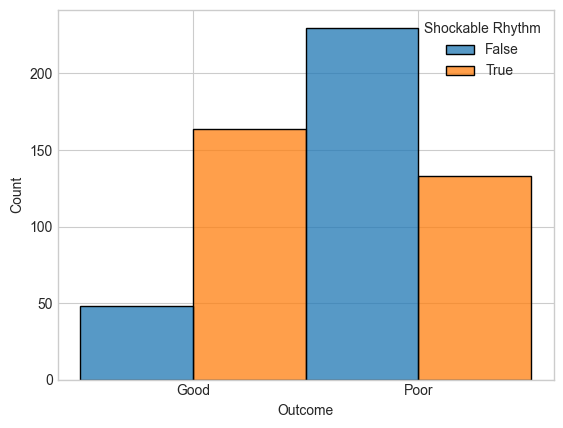

In [18]:
sns.histplot(data=df, hue="Shockable Rhythm", x="Outcome",multiple="dodge")

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id_Patient        607 non-null    int64  
 1   Hospital          607 non-null    object 
 2   Age               607 non-null    float64
 3   Sex               607 non-null    object 
 4   ROSC              303 non-null    float64
 5   OHCA              566 non-null    object 
 6   Shockable Rhythm  575 non-null    object 
 7   TTM               509 non-null    float64
 8   Outcome           607 non-null    object 
 9   CPC               607 non-null    int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 47.6+ KB


In [63]:
dict_hospital={"A":1, "B":2, "C":3, "D":4, "E":5, "F":6}
dict_sex={"Male":1, "Female":2}
dict_outcome={"Good":1, "Poor":2}

# Results

In [4]:
list_models

['results_2.pkl',
 'results_1.pkl',
 'results_3.pkl',
 'results_4.pkl',
 'results_5.pkl',
 'results.pkl']

In [5]:
path="F:/Cerebro/Mapi/"
list_models=os.listdir(path)
list_models=[x for x in list_models if ".pkl" in x]
list_models
with open(path+list_models[-1], "rb") as f:
    model=pkl.load(f)
model.keys()

dict_keys(['h_24_28_32_36', 'h_28_32_36_40', 'h_30_34_38_42', 'h_32_36_40_44', 'h_34_38_42_46', 'h_24_28_32_36_dif', 'h_32_36_40_44_dif', 'h_34_38_42_46_dif', 'h_28_32_36_40dif', 'h_30_34_38_42dif'])